In [2]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd
import tqdm
import numpy as np
import os
import glob
from uncertainties import unumpy as unp


In [3]:
fpaths = sorted(glob.glob("/afs/cern.ch/user/b/bewilson/eos/saturation_rate_checks/*.root"), key=lambda x: int(os.path.basename(x).split(".")[0]))
print(f"found {len(fpaths)} files")

found 555 files


In [4]:
def parse_grl_csv(grl_csv_path):
    grl_df = pd.read_csv(grl_csv_path, comment="#")
    grl_df["run"] = grl_df["Run"].astype(int)
    grl_df["lumi"] = grl_df[" LumiRec"].astype(int)
    return grl_df

In [5]:
grl_2022_df = parse_grl_csv("/cvmfs/faser.cern.ch/repo/sw/runlist/v10/faser_goodrunlist_2022_physics.csv")
grl_2023_df = parse_grl_csv("/cvmfs/faser.cern.ch/repo/sw/runlist/v10/faser_goodrunlist_2023_physics.csv")
grl_2024_df = parse_grl_csv("/cvmfs/faser.cern.ch/repo/sw/runlist/v10/faser_goodrunlist_2024_physics.csv")
grl_df = pd.concat([grl_2022_df, grl_2023_df, grl_2024_df], ignore_index=True)
good_runs = set(grl_df["run"].values)

In [6]:
cutflow = {}

run_yields = {}

for fpath in tqdm.tqdm(fpaths):
    with uproot.open(fpath) as f:
        tree = f["cutflow"]
        lumi = f["meta"].arrays(library="pd")["lumi"][0]
        df = tree.arrays(library="pd")

        run = int(os.path.basename(fpath).split("/")[-1].split(".")[0])

        if run not in good_runs:
            continue
        
    for idx, row in df.iterrows():
        cut = row["cut_name"]
        all = row["all"]
        passed = row["passed"]

        if cut not in cutflow:
            cutflow[cut] = {"all": 0, "passed": 0}

        cutflow[cut]["all"] += all
        cutflow[cut]["passed"] += passed
    
    all_events = np.amax(df["all"])
    final_yield = np.amin(df["passed"])

    lumi_ = 0
    if len(lumi) > 0 and lumi[0] > 0:
        lumi_ = float(lumi[0])

    run_yields[run] = {"lumi": lumi_, "all": all_events, "passed": final_yield}
    # print(f"Run {run}: lumi={lumi_}, all={all_events}, passed={final_yield}")


100%|██████████| 555/555 [00:51<00:00, 10.81it/s]


In [7]:
def legend(ax):
    handles, labels = ax.get_legend_handles_labels()
    unique = [
        (h, l)
        for i, (h, l) in enumerate(zip(handles, labels))
        if l not in labels[:i]
    ]
    ax.legend(*zip(*unique), frameon=False)

In [8]:
def plot_track_yields(cutflow_dict):

    fig, ax = plt.subplots(figsize=(48, 6))
    run_numbers = []
    lumis = []
    def plot_yield_for_run(lumi, event_yield):
        
        if lumi <= 0 or event_yield <= 0:
            return False

        lumi = unp.uarray(lumi, 0.022 * lumi)
        yield_arr = unp.uarray(event_yield, np.sqrt(event_yield))/lumi
        
        ax.errorbar([index], unp.nominal_values(yield_arr), yerr=unp.std_devs(yield_arr), xerr=0.5, linestyle="", linewidth=1, color='blue', label="Event Yield")
        return True

    index = 0
    indices = []

    index_end_2022 = 0
    index_end_2023 = 0
    index_end_2024 = 0

    for i, (run, run_dict) in enumerate(cutflow_dict.items()):
        # print(run_dict)
        # print(run, run_dict["lumi"], run_dict["passed"])
        if plot_yield_for_run(run_dict["lumi"], run_dict["passed"]):
            indices.append(index)
            index += 1
            run_numbers.append(run)

            if run == 9188:
                index_end_2022 = index
            if run == 11703:
                index_end_2023 = index
            if run == 17230:
                index_end_2024 = index

    ax.axvline(index_end_2022 - 0.5, color="k", linestyle="--",)
    ax.axvline(index_end_2023 - 0.5, color="k", linestyle="--",)

    ax.set_ylim(0, 1.1 * ax.get_ylim()[1])
    ax.text(index_end_2022 / 2, ax.get_ylim()[1] * 0.98, "2022", fontsize=18, ha="center", va="top",)
    ax.text(index_end_2022/2 + index_end_2023 / 2, ax.get_ylim()[1] * 0.98, "2023", fontsize=18, ha="center", va="top",)
    ax.text(index_end_2023/2 + index_end_2024 / 2, ax.get_ylim()[1] * 0.98, "2024", fontsize=18, ha="center", va="top",)

    ax.set_ylabel("Saturated PS events [1/pb]", fontsize=14)

    ax.set_xlim(indices[0] - 0.5, indices[-1] + 0.5)
    ax.set_xticks(indices)
    ax.set_xticklabels(run_numbers, rotation="vertical", fontsize=8)
    legend(ax)
    plt.savefig("VetoNuTrig_SaturatedPS_Yield.png", dpi=300)
    plt.savefig("VetoNuTrig_SaturatedPS_Yield.pdf", dpi=300)

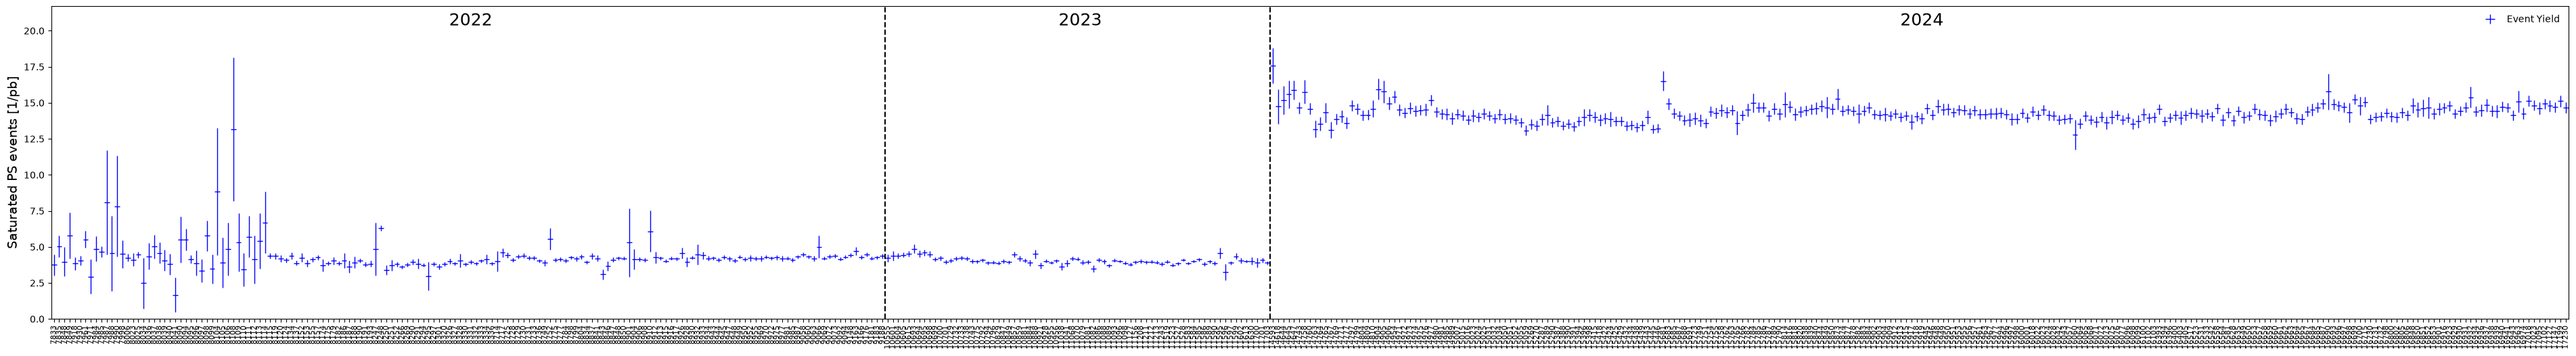

In [9]:
plot_track_yields(run_yields)

In [14]:
import awkward as ak
from copy import deepcopy
import boost_histogram as bh
import mplhep

def apply_cuts(root_file_path, edges):

    with uproot.open(root_file_path) as f:
        tree = f["nt"]
        lumi = f["meta"].arrays(library="pd")["lumi"][0]
        if len(lumi) > 0 and lumi[0] > 0:
            lumi_ = float(lumi[0])
        else:
            lumi_ = 0.0

        arr = tree.arrays(["longTracks", "Track_pz0"], library="ak")
        run = int(os.path.basename(root_file_path).split("/")[-1].split(".")[0])
        
        pz_hist = bh.Histogram(bh.axis.Variable(edges))

        # select events with at least one long track
        long_tracks_mask = arr["longTracks"] > 0
        selected_events = arr[long_tracks_mask]

        # Get pz of leading track (assuming Track_pz0 is an array of pz values for tracks)
        leading_track_pz = ak.max(selected_events["Track_pz0"], axis=1) / 1000
        pz_hist.fill(leading_track_pz)
        # pz_hist /= lumi[0] if len(lumi) > 0 and lumi[0] > 0 else 1.0
    return {run: {"h": pz_hist, "lumi": lumi_}}

In [46]:
run_hist_dict = {}
edges = [10, 50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1500, 2000]
centers = [(edges[i] + edges[i+1]) / 2 for i in range(len(edges)-1)]

for fpath in tqdm.tqdm(fpaths):
    run_hist_dict.update(apply_cuts(fpath, edges))

100%|██████████| 555/555 [01:28<00:00,  6.27it/s]


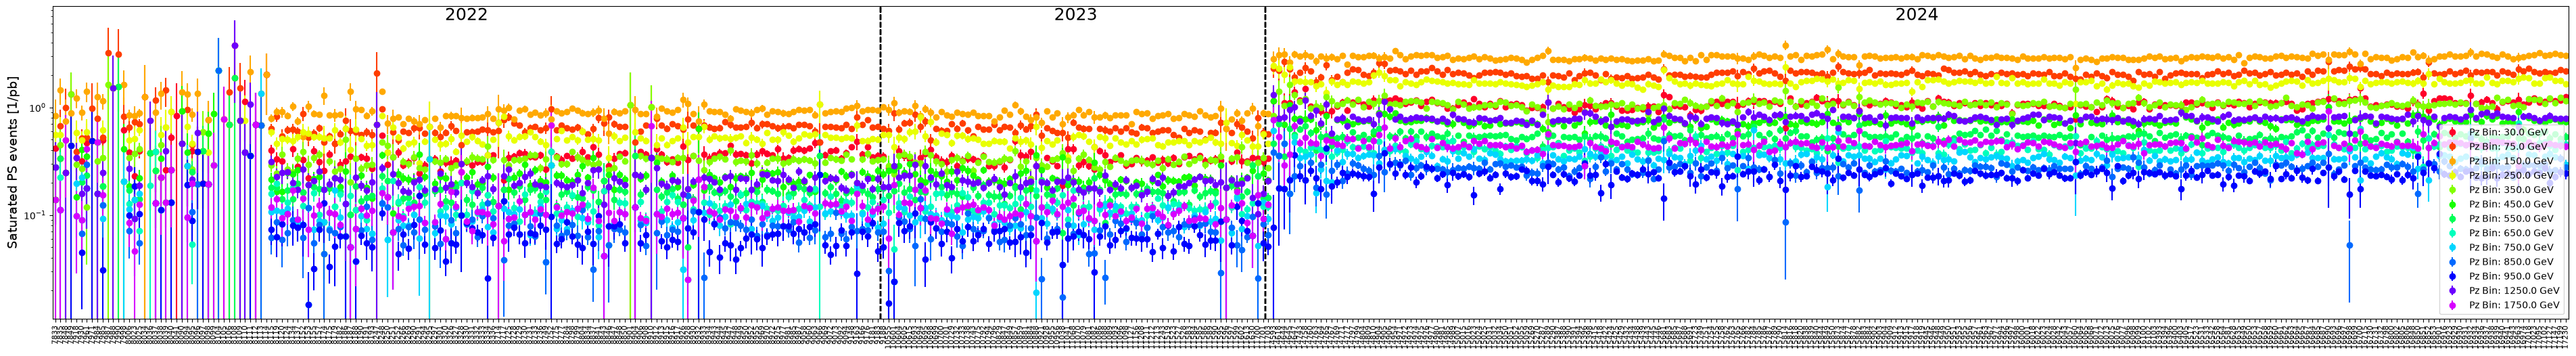

In [50]:

# Plot yields for each run for each pz bin
fig, ax = plt.subplots(figsize=(48, 6))
centers = [(edges[i] + edges[i+1]) / 2 for i in range(len(edges)-1)]

cm = plt.get_cmap('gist_rainbow')
ax.set_prop_cycle('color', [cm(1.*i/len(centers)) for i in range(len(centers))])

for bin_center in centers:
    bin_yields = []
    bin_errors = []
    run_numbers = []

    index = 0
    indices = []
    index_end_2022 = 0
    index_end_2023 = 0
    index_end_2024 = 0


    for run, pz_hist in run_hist_dict.items():
        
        lumi = pz_hist["lumi"]
        hist = pz_hist["h"]
        if lumi == 0:
            continue
        
        index += 1
        indices.append(index)
        
        # Get the bin index for the current bin center
        bin_index = np.digitize(bin_center, edges) - 1

        if 0 <= bin_index < len(hist.values()):
            yield_value = hist[bin_index] / lumi if lumi > 0 else 0
            error_value = np.sqrt(hist[bin_index]) / lumi if lumi > 0 else 0

            yield_value = yield_value #/ hist.sum(flow=True) if hist.sum(flow=True) > 0 else 0
            error_value = error_value #/ hist.sum(flow=True) if hist.sum(flow=True) > 0 else 0

            bin_yields.append(yield_value)
            bin_errors.append(error_value)
            run_numbers.append(run)
    
        if run == 9188:
            index_end_2022 = index
        if run == 11703:
            index_end_2023 = index
        if run == 17230:
            index_end_2024 = index

    ax.axvline(index_end_2022 - 0.5, color="k", linestyle="--",)
    ax.axvline(index_end_2023 - 0.5, color="k", linestyle="--",)


    ax.errorbar(indices, bin_yields, yerr=bin_errors, fmt='o', label=f'Pz Bin: {bin_center} GeV')
    
# ax.set_ylim(0, 1.1 * ax.get_ylim()[1])
ax.set_xlim(indices[0] - 0.5, indices[-1] + 0.5)
ax.set_xticks(indices)
ax.set_xticklabels(run_numbers, rotation="vertical", fontsize=8)
ax.set_yscale('log')

ax.legend()
ax.text(index_end_2022 / 2, ax.get_ylim()[1] * 0.98, "2022", fontsize=18, ha="center", va="top",)
ax.text(index_end_2022/2 + index_end_2023 / 2, ax.get_ylim()[1] * 0.98, "2023", fontsize=18, ha="center", va="top",)
ax.text(index_end_2023/2 + index_end_2024 / 2, ax.get_ylim()[1] * 0.98, "2024", fontsize=18, ha="center", va="top",)
ax.set_ylabel("Saturated PS events [1/pb]", fontsize=14)
plt.savefig("VetoNuTrig_SaturatedPS_Yield_byPzBin.png", dpi=300)
plt.savefig("VetoNuTrig_SaturatedPS_Yield_byPzBin.pdf", dpi=300)

In [54]:
def plot_track_yields_by_bin(run_hist_dict, edges):

    fig, ax = plt.subplots(figsize=(48, 6))
    run_numbers = []
    lumis = []
    centers = [(edges[i] + edges[i+1]) / 2 for i in range(len(edges)-1)]

    def plot_yield_for_run(lumi, event_yield):
        
        if lumi <= 0 or event_yield <= 0:
            return False

        lumi = unp.uarray(lumi, 0.022 * lumi)
        yield_arr = unp.uarray(event_yield, np.sqrt(event_yield))/lumi
        
        ax.errorbar([index], unp.nominal_values(yield_arr), yerr=unp.std_devs(yield_arr), xerr=0.5, linestyle="", linewidth=1, color='blue', label="Event Yield")
        return True

    index = 0
    indices = []

    index_end_2022 = 0
    index_end_2023 = 0
    index_end_2024 = 0

    for bin_center in centers:
        for i, (run, run_dict) in enumerate(run_hist_dict.items()):
            # print(run_dict)
            # print(run, run_dict["lumi"], run_dict["passed"])
            if plot_yield_for_run(run_dict["lumi"], run_dict["passed"]):
                indices.append(index)
                index += 1
                run_numbers.append(run)

                if run == 9188:
                    index_end_2022 = index
                if run == 11703:
                    index_end_2023 = index
                if run == 17230:
                    index_end_2024 = index

    ax.axvline(index_end_2022 - 0.5, color="k", linestyle="--",)
    ax.axvline(index_end_2023 - 0.5, color="k", linestyle="--",)

    ax.set_ylim(0, 1.1 * ax.get_ylim()[1])
    ax.text(index_end_2022 / 2, ax.get_ylim()[1] * 0.98, "2022", fontsize=18, ha="center", va="top",)
    ax.text(index_end_2022/2 + index_end_2023 / 2, ax.get_ylim()[1] * 0.98, "2023", fontsize=18, ha="center", va="top",)
    ax.text(index_end_2023/2 + index_end_2024 / 2, ax.get_ylim()[1] * 0.98, "2024", fontsize=18, ha="center", va="top",)

    ax.set_ylabel("Saturated PS events [1/pb]", fontsize=14)

    ax.set_xlim(indices[0] - 0.5, indices[-1] + 0.5)
    ax.set_xticks(indices)
    ax.set_xticklabels(run_numbers, rotation="vertical", fontsize=8)
    legend(ax)
    plt.savefig("VetoNuTrig_SaturatedPS_Yield.png", dpi=300)
    plt.savefig("VetoNuTrig_SaturatedPS_Yield.pdf", dpi=300)

In [62]:
import awkward as ak
from copy import deepcopy
import boost_histogram as bh
import mplhep

def apply_veto_cuts(root_file_path):

    with uproot.open(root_file_path) as f:
        tree = f["nt"]
        lumi = f["meta"].arrays(library="pd")["lumi"][0]
        if len(lumi) > 0 and lumi[0] > 0:
            lumi_ = float(lumi[0])
        else:
            lumi_ = 0.0

        arr = tree.arrays(["VetoNu0_raw_charge", "VetoNu1_raw_charge"], library="ak")
        run = int(os.path.basename(root_file_path).split("/")[-1].split(".")[0])
        
        pz_hist = bh.Histogram(bh.axis.Variable(edges))

        # select events with vetoNu0 and VetoNu1 charge < 40 
        vetoNu0_mask = arr["VetoNu0_raw_charge"] < 40
        vetoNu1_mask = arr["VetoNu1_raw_charge"] < 40
        selected_events = arr[vetoNu0_mask & vetoNu1_mask]

    return {run: {"lumi": lumi_, "all": len(selected_events), "passed": len(selected_events)}}

In [63]:
run_vetoCut_dict = {}
for fpath in tqdm.tqdm(fpaths):
    run_vetoCut_dict.update(apply_veto_cuts(fpath))

100%|██████████| 555/555 [03:12<00:00,  2.88it/s]


In [64]:
run_vetoCut_dict

{7729: {'lumi': 0.0, 'all': 0, 'passed': 0},
 7733: {'lumi': 0.0, 'all': 0, 'passed': 0},
 7734: {'lumi': 0.0, 'all': 0, 'passed': 0},
 7802: {'lumi': 0.0, 'all': 0, 'passed': 0},
 7833: {'lumi': 7.178999900817871, 'all': 0, 'passed': 0},
 7835: {'lumi': 8.9399995803833, 'all': 0, 'passed': 0},
 7836: {'lumi': 0.0, 'all': 0, 'passed': 0},
 7848: {'lumi': 4.019000053405762, 'all': 0, 'passed': 0},
 7849: {'lumi': 2.25, 'all': 0, 'passed': 0},
 7918: {'lumi': 20.507999420166016, 'all': 0, 'passed': 0},
 7930: {'lumi': 44.441001892089844, 'all': 0, 'passed': 0},
 7961: {'lumi': 17.0310001373291, 'all': 0, 'passed': 0},
 7971: {'lumi': 2.0429999828338623, 'all': 0, 'passed': 0},
 7984: {'lumi': 6.361999988555908, 'all': 0, 'passed': 0},
 7985: {'lumi': 32.415000915527344, 'all': 0, 'passed': 0},
 7987: {'lumi': 0.6190000176429749, 'all': 0, 'passed': 0},
 7988: {'lumi': 0.6600000262260437, 'all': 0, 'passed': 0},
 7989: {'lumi': 0.0, 'all': 0, 'passed': 0},
 7990: {'lumi': 0.63899999856948

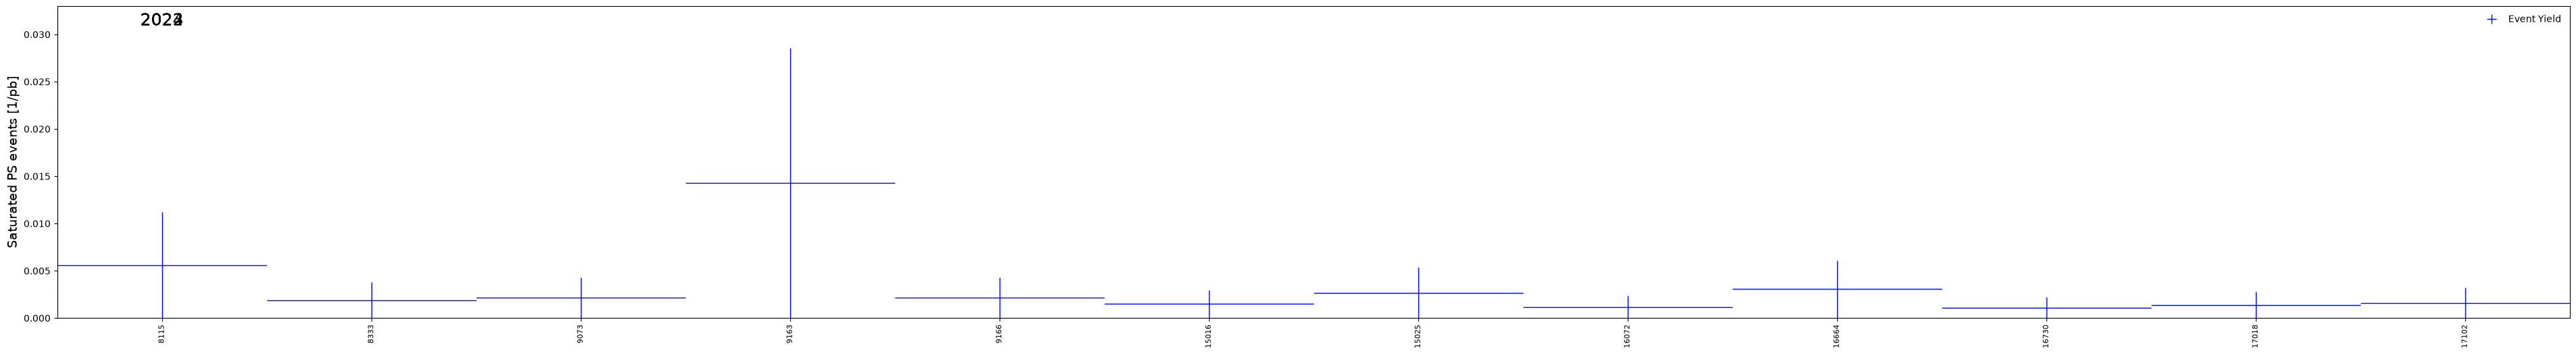

In [65]:
plot_track_yields(run_vetoCut_dict)